In [5]:
# IMPORT LIBRARIES
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os
import pathlib

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.18.0


# EDA

Found 3 classes:
['Angry', 'Happy', 'Sad']

Images per class:
Angry: 150 images
Happy: 150 images
Sad: 150 images


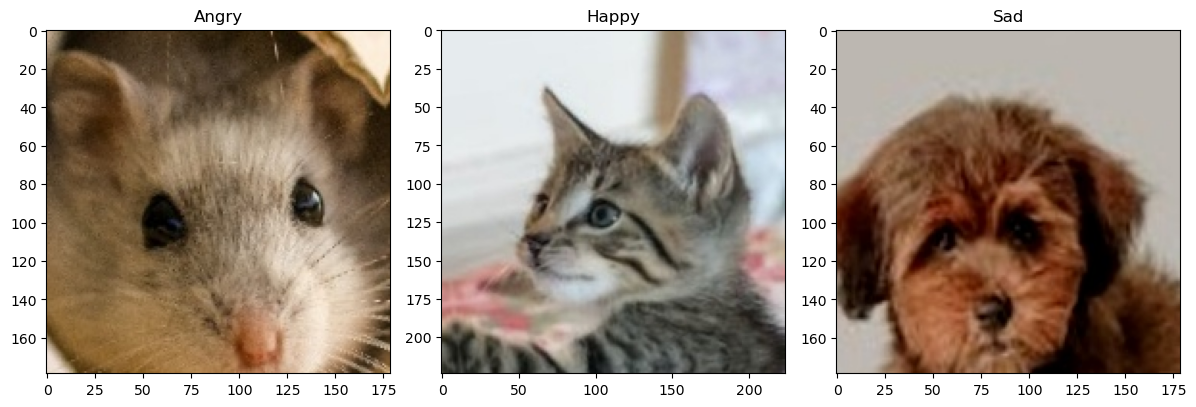

In [7]:
# Load Data
train_directory = pathlib.Path('./data/train')
test_directory = pathlib.Path('./data/test')

if not train_directory.exists():
    # JupyterHub path
    train_directory = pathlib.Path('/home/jovyan/Data/train')
    test_directory = pathlib.Path('/home/jovyan/Data/test')
    

class_names = sorted([d for d in os.listdir(train_directory) 
                      if os.path.isdir(os.path.join(train_directory, d))])
print(f"Found {len(class_names)} classes:")
print(class_names)

# Count images per class
print("\nImages per class:")
for class_name in class_names:
    class_path = os.path.join(train_directory, class_name)
    num_images = len([f for f in os.listdir(class_path) 
                      if f.endswith(('.jpg', '.jpeg', '.png'))])
    print(f"{class_name}: {num_images} images")

# Display sample images
plt.figure(figsize=(12, 8))
for i, class_name in enumerate(class_names):  
    class_path = os.path.join(train_directory, class_name)
    img_files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
    if img_files:
        img_path = os.path.join(class_path, img_files[0])
        img = plt.imread(img_path)
        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.title(class_name)
plt.tight_layout()
plt.show()

# Data Rescale

In [8]:
IMG_SIZE = 128
BATCH_SIZE = 32

datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Load training data
train_data = datagen.flow_from_directory(
    train_directory,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = datagen.flow_from_directory(
    train_directory, 
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation', 
    shuffle=True
)


test_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
)

# Load test data
test_data = test_datagen.flow_from_directory(
    test_directory,
    target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
    class_mode = None,
    shuffle= False
)

print(f"Training samples: {train_data.samples}")
print(f"Validating samples: {val_data.samples}")
print(f"Test samples: {test_data.samples}")
print(f"Class mapping: {train_data.class_indices}")

Found 360 images belonging to 3 classes.
Found 90 images belonging to 3 classes.
Found 0 images belonging to 0 classes.
Training samples: 360
Validating samples: 90
Test samples: 0
Class mapping: {'Angry': 0, 'Happy': 1, 'Sad': 2}


# Build Model

In [ ]:
model = keras.Sequential([
    # First conv block
    layers.Conv2D(32, (3,3), activation='relu', padding='same', 
                  input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2,2),
    
    # Second conv block
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),
    
    # Third conv block
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),
    
    # Classifier
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

model.summary()

# Train Model

In [ ]:
# COMPILE
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    verbose=1
)

# Prediction

In [ ]:
# Make predictions on test data
predictions = model.predict(test_data)
print(f"Predictions shape: {predictions.shape}")

# Get predicted class for each image
predicted_classes = np.argmax(predictions, axis=1)
print(f"Predicted class indices: {predicted_classes[:10]}")

# Convert to emotion names
class_names = list(train_data.class_indices.keys())
predicted_emotions = [class_names[i] for i in predicted_classes]

print(f"Predicted emotions (first 10): {predicted_emotions[:10]}")

# Save results
import pandas as pd

results = pd.DataFrame({
    'predicted_class': predicted_classes,
    'predicted_emotion': predicted_emotions,
    'prob_angry': predictions[:, 0],
    'prob_happy': predictions[:, 1],
    'prob_sad': predictions[:, 2]
})

print(results.head(10))

results.to_csv('test_predictions.csv', index=False)

# Evaluate

In [ ]:
# Plot
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Final accuracy
val_loss, val_acc = model.evaluate(val_data)
print(f"\nFinal Validation Accuracy: {val_acc:.4f}")